In [1]:
import pandas as pd
import pysam
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Load the VCF file into a DataFrame for analysis
vcf_file_path = '../output.vcf'

# Define function to parse VCF file
def parse_vcf(vcf_file):
    # Store data in a list to create DataFrame later
    vcf_data = []
    headers = []

    with open(vcf_file, 'r') as file:
        for line in file:
            if line.startswith("##"):
                # Skip metadata lines
                continue
            elif line.startswith("#"):
                # Column headers
                headers = line.strip().split("\t")
            else:
                # Variant data
                vcf_data.append(line.strip().split("\t"))

    # Create DataFrame
    vcf_df = pd.DataFrame(vcf_data, columns=headers)
    return vcf_df

# Parse the VCF file and load it into a DataFrame
vcf_df = parse_vcf(vcf_file_path)

print(vcf_df.shape)

# Display the first few rows to understand the structure
vcf_df.head()

(24480, 10)


,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,SAMPLE
0,chr1,136934,Sniffles2.INS.1S0,N,CAAGGGGCTCGGGCTGACCTCTCTCAGTGTGGGAGGGGCCGGTGTG...,52,PASS,PRECISE;SVTYPE=INS;SVLEN=244;END=136934;SUPPOR...,GT:GQ:DR:DV,1/1:36:0:13
1,chr1,181176,Sniffles2.INS.4S0,N,GCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGCGCAGA...,58,PASS,PRECISE;SVTYPE=INS;SVLEN=174;END=181176;SUPPOR...,GT:GQ:DR:DV,0/1:26:4:5
2,chr1,181210,Sniffles2.DEL.81AS0,N,<DEL>,55,PASS,PRECISE;SVTYPE=DEL;SVLEN=-239;END=181449;SUPPO...,GT:GQ:DR:DV,0/1:60:10:14
3,chr1,181229,Sniffles2.INS.3S0,N,GCCGCGCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGC...,27,PASS,PRECISE;SVTYPE=INS;SVLEN=105;END=181229;SUPPOR...,GT:GQ:DR:DV,0/1:26:5:4
4,chr1,369264,Sniffles2.INS.8S0,N,GTGTGGAAACTGCGACACTCACGCGGGTGCCGTCTCAGCAGCTCAC...,25,GT,IMPRECISE;SVTYPE=INS;SVLEN=189;END=369264;SUPP...,GT:GQ:DR:DV,0/0:10:18:4


## Data Analysis

### 1. Variant Distribution Across Chromosomes

Text(0.5, 1.0, 'Variant Type Counts')

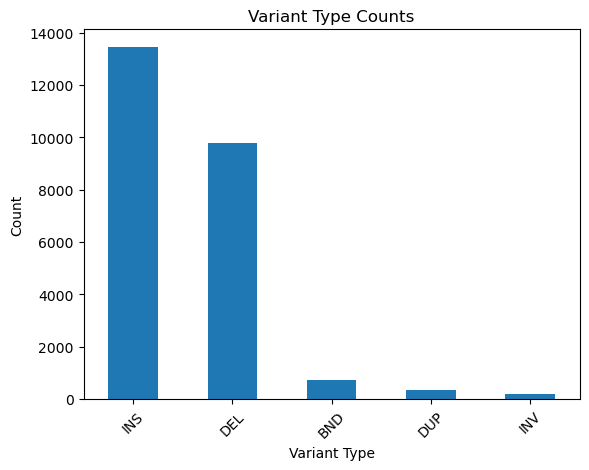

In [4]:
# Summarize counts for each variant type (insertion, deletion, etc.)
variant_counts = vcf_df['INFO'].str.extract(r'SVTYPE=([A-Z]+)')[0].value_counts()
# Create a bar plot of the variant counts. Angle the x-axis labels for better readability.
variant_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Variant Type')
plt.ylabel('Count')
plt.title('Variant Type Counts')

Text(0.5, 1.0, 'Variant Type Counts')

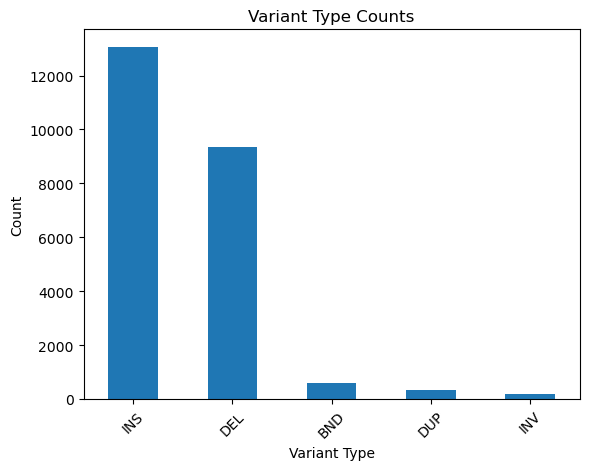

In [5]:
# Filter the DataFrame to include only standard chromosomes (chr1 through chr22, chrX, chrY)
standard_chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
filtered_vcf_df = vcf_df[vcf_df['#CHROM'].isin(standard_chromosomes)]

filtered_variant_counts = filtered_vcf_df['INFO'].str.extract(r'SVTYPE=([A-Z]+)')[0].value_counts()

# Create a bar plot of the variant counts. Angle the x-axis labels for better readability.
filtered_variant_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Variant Type')
plt.ylabel('Count')
plt.title('Variant Type Counts')

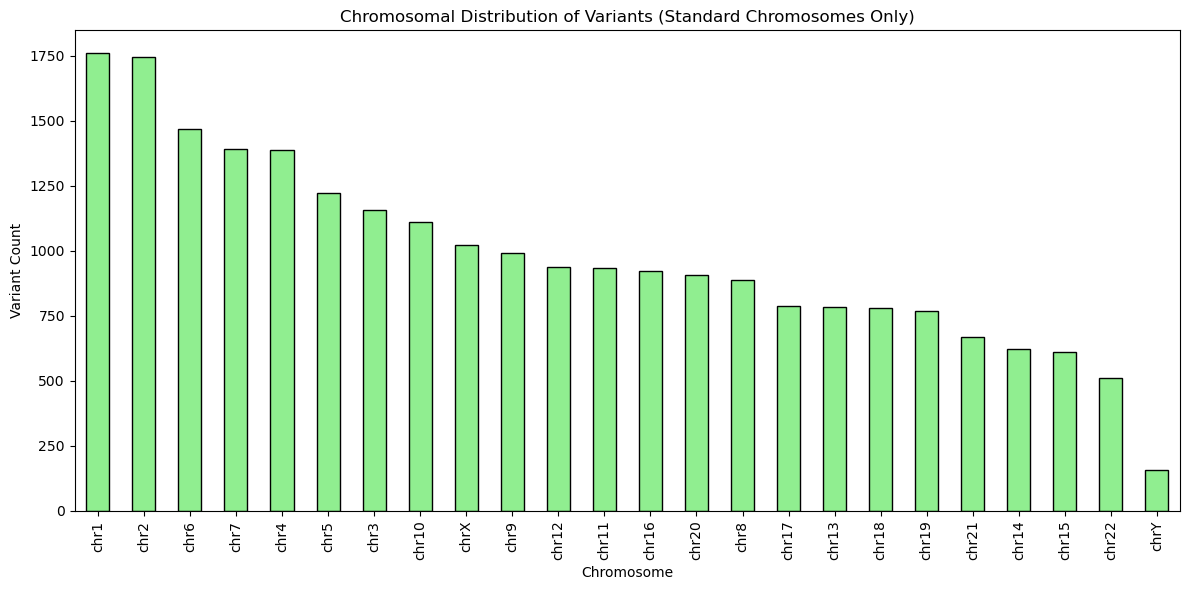

In [6]:
# Recalculate the chromosome counts with only standard chromosomes
filtered_chromosome_counts = filtered_vcf_df['#CHROM'].value_counts()

# Plot 1: Chromosomal Distribution of Variants - Bar Plot (Standard Chromosomes Only)
plt.figure(figsize=(12, 6))
filtered_chromosome_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Chromosomal Distribution of Variants (Standard Chromosomes Only)")
plt.xlabel("Chromosome")
plt.ylabel("Variant Count")
plt.xticks(rotation=90)
plt.tight_layout()

C:\Users\deoxy\AppData\Local\Temp\ipykernel_26016\1090048571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_vcf_df['SVTYPE'] = filtered_vcf_df['INFO'].str.extract(r'SVTYPE=([A-Z]+)')


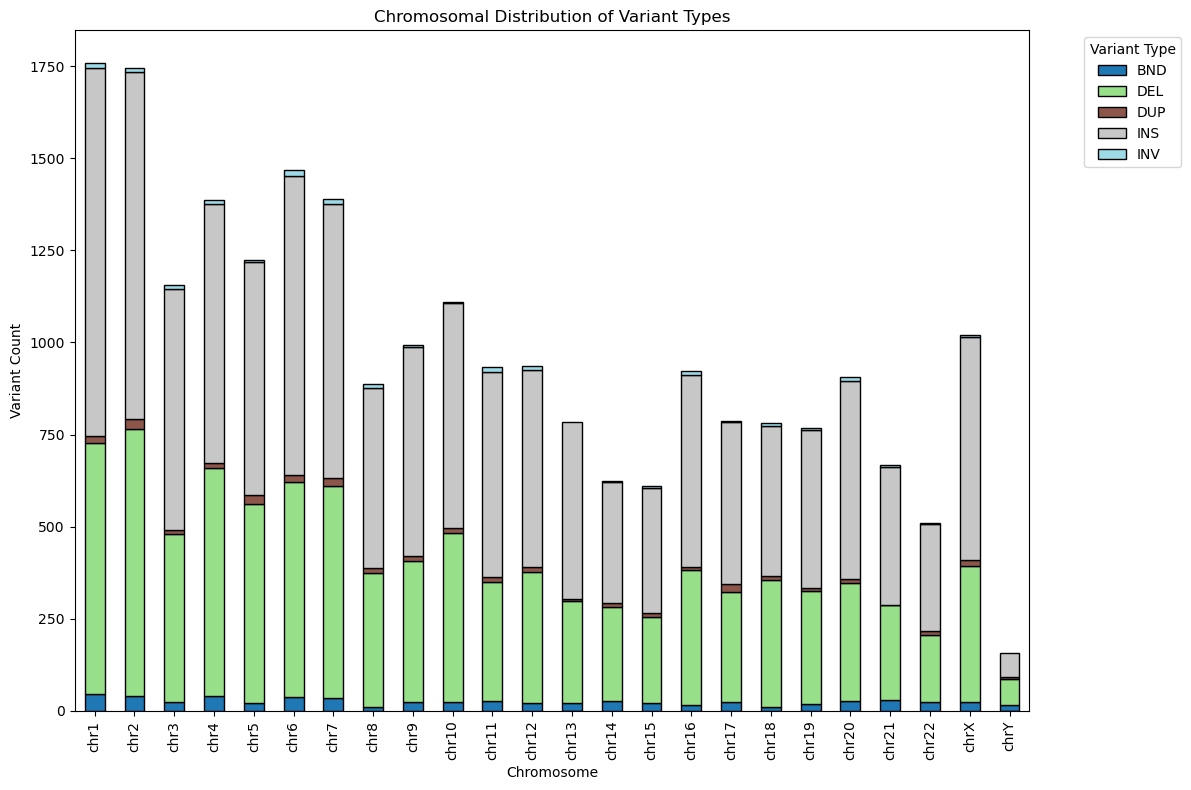

In [8]:
# Extract variant type from INFO column and add as a new column
filtered_vcf_df['SVTYPE'] = filtered_vcf_df['INFO'].str.extract(r'SVTYPE=([A-Z]+)')

# Calculate counts of each variant type per chromosome
variant_type_counts = filtered_vcf_df.groupby(['#CHROM', 'SVTYPE']).size().unstack(fill_value=0)
variant_type_counts = variant_type_counts.reindex(standard_chromosomes)  # Ensure correct chromosome order

# Plot stacked bar plot with each variant type in different colors
plt.figure(figsize=(12, 8))
variant_type_counts.plot(kind='bar', stacked=True, colormap="tab20", edgecolor='black', ax=plt.gca())
plt.title("Chromosomal Distribution of Variant Types")
plt.xlabel("Chromosome")
plt.ylabel("Variant Count")
plt.legend(title="Variant Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()

In [ ]:
# Summarize counts for each variant type (insertion, deletion, etc.)
variant_counts = vcf_df['INFO'].str.extract(r'SVTYPE=([A-Z]+)')[0].value_counts()

# Filter based on quality (QUAL >= 30 as a threshold for high-quality calls)
high_quality_variants = vcf_df[vcf_df['QUAL'].astype(float) >= 30]

# Filter based on support (e.g., SUPPORT >= 10 to indicate variants with high support)
# First, extract the SUPPORT value from the INFO column
vcf_df['SUPPORT'] = vcf_df['INFO'].str.extract(r'SUPPORT=(\d+)').astype(float)
high_support_variants = vcf_df[vcf_df['SUPPORT'] >= 10]

# Analyze specific chromosomes or positions
# Group by chromosome and count variants per chromosome
chromosome_counts = vcf_df['#CHROM'].value_counts()

variant_counts, chromosome_counts

## Size Distribution Plot

In [3]:
vcf_df.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,SAMPLE
0,chr1,136934,Sniffles2.INS.1S0,N,CAAGGGGCTCGGGCTGACCTCTCTCAGTGTGGGAGGGGCCGGTGTG...,52,PASS,PRECISE;SVTYPE=INS;SVLEN=244;END=136934;SUPPOR...,GT:GQ:DR:DV,1/1:36:0:13
1,chr1,181176,Sniffles2.INS.4S0,N,GCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGCGCAGA...,58,PASS,PRECISE;SVTYPE=INS;SVLEN=174;END=181176;SUPPOR...,GT:GQ:DR:DV,0/1:26:4:5
2,chr1,181210,Sniffles2.DEL.81AS0,N,<DEL>,55,PASS,PRECISE;SVTYPE=DEL;SVLEN=-239;END=181449;SUPPO...,GT:GQ:DR:DV,0/1:60:10:14
3,chr1,181229,Sniffles2.INS.3S0,N,GCCGCGCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGC...,27,PASS,PRECISE;SVTYPE=INS;SVLEN=105;END=181229;SUPPOR...,GT:GQ:DR:DV,0/1:26:5:4
4,chr1,369264,Sniffles2.INS.8S0,N,GTGTGGAAACTGCGACACTCACGCGGGTGCCGTCTCAGCAGCTCAC...,25,GT,IMPRECISE;SVTYPE=INS;SVLEN=189;END=369264;SUPP...,GT:GQ:DR:DV,0/0:10:18:4


In [9]:
filtered_vcf_df.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,SAMPLE,SVTYPE
0,chr1,136934,Sniffles2.INS.1S0,N,CAAGGGGCTCGGGCTGACCTCTCTCAGTGTGGGAGGGGCCGGTGTG...,52,PASS,PRECISE;SVTYPE=INS;SVLEN=244;END=136934;SUPPOR...,GT:GQ:DR:DV,1/1:36:0:13,INS
1,chr1,181176,Sniffles2.INS.4S0,N,GCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGCGCAGA...,58,PASS,PRECISE;SVTYPE=INS;SVLEN=174;END=181176;SUPPOR...,GT:GQ:DR:DV,0/1:26:4:5,INS
2,chr1,181210,Sniffles2.DEL.81AS0,N,<DEL>,55,PASS,PRECISE;SVTYPE=DEL;SVLEN=-239;END=181449;SUPPO...,GT:GQ:DR:DV,0/1:60:10:14,DEL
3,chr1,181229,Sniffles2.INS.3S0,N,GCCGCGCCGGCGCAGGCGCAGAGAGGCGCGCCGCGCCGGCGCAGGC...,27,PASS,PRECISE;SVTYPE=INS;SVLEN=105;END=181229;SUPPOR...,GT:GQ:DR:DV,0/1:26:5:4,INS
4,chr1,369264,Sniffles2.INS.8S0,N,GTGTGGAAACTGCGACACTCACGCGGGTGCCGTCTCAGCAGCTCAC...,25,GT,IMPRECISE;SVTYPE=INS;SVLEN=189;END=369264;SUPP...,GT:GQ:DR:DV,0/0:10:18:4,INS


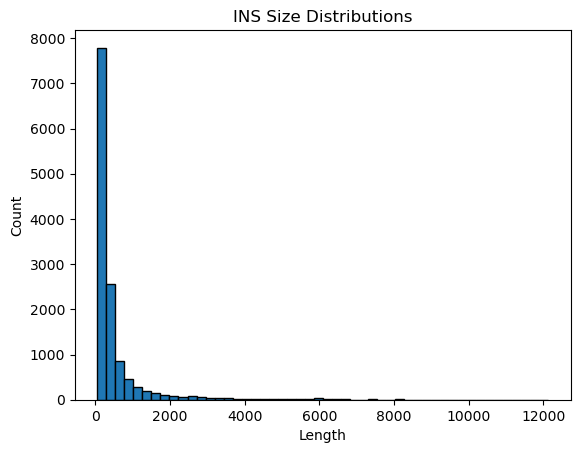

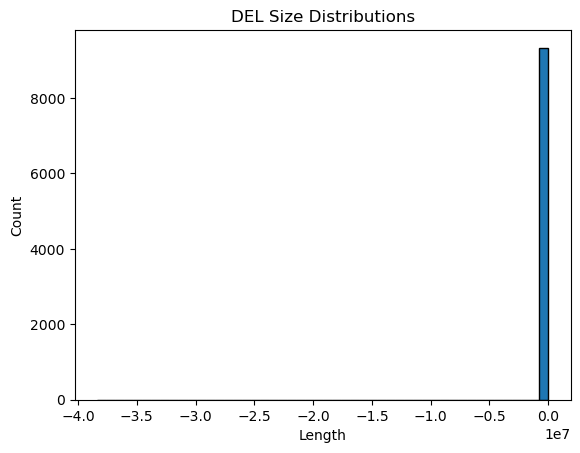

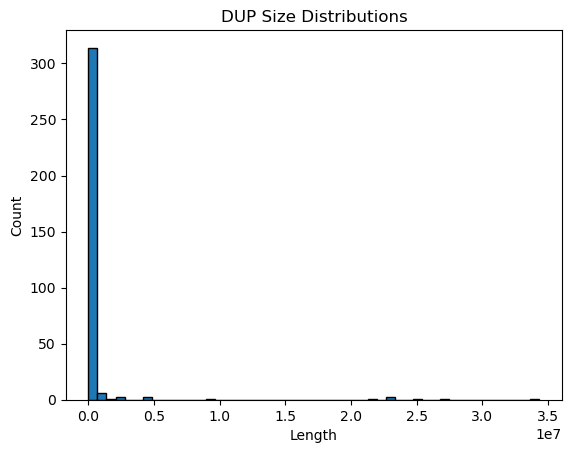

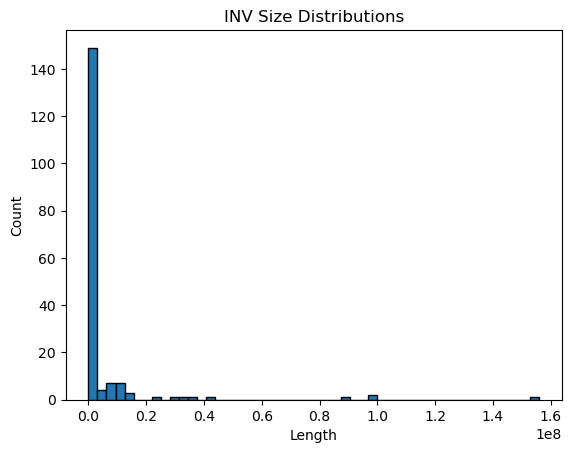

In [37]:
def count_size_distrib_of_variants(df, svtype):
    """Compute the size distribution of a specific type of variant"""
    plt.clf()
    variant_spec_data = df[df['SVTYPE'] == svtype]
    lengths = variant_spec_data['INFO'].str.extract(r'SVLEN=(-?[0-9]+)')[0]
    
    lengths = lengths[lengths.notnull()].astype(int)
    plt.hist(lengths, edgecolor='black', bins=50)
    plt.title(f'{svtype} Size Distributions')
    plt.xlabel('Length')
    plt.ylabel('Count')
    plt.show()

count_size_distrib_of_variants(filtered_vcf_df, "INS")
count_size_distrib_of_variants(filtered_vcf_df, "DEL")
count_size_distrib_of_variants(filtered_vcf_df, "DUP")
count_size_distrib_of_variants(filtered_vcf_df, "INV")

In [36]:
t = filtered_vcf_df[filtered_vcf_df['SVTYPE'] == 'BND']
t.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,SAMPLE,SVTYPE
12,chr1,587107,Sniffles2.BND.26E7S0,N,N]chr2:242159196],60,PASS,"PRECISE;SVTYPE=BND;SUPPORT=4;COVERAGE=1,1,5,4,...",GT:GQ:DR:DV,1/1:11:0:4,BND
26,chr1,882985,Sniffles2.BND.26F4S0,N,N]chr20:29780989],57,PASS,"PRECISE;SVTYPE=BND;SUPPORT=13;COVERAGE=175,74,...",GT:GQ:DR:DV,0/1:40:32:13,BND
27,chr1,883001,Sniffles2.BND.26F3S0,N,]chr20:29345706]N,60,PASS,"IMPRECISE;SVTYPE=BND;SUPPORT=21;COVERAGE=174,2...",GT:GQ:DR:DV,0/1:41:10:21,BND
28,chr1,883001,Sniffles2.BND.26F6S0,N,[chr20:30866925[N,58,PASS,"PRECISE;SVTYPE=BND;SUPPORT=32;COVERAGE=174,29,...",GT:GQ:DR:DV,1/1:60:0:32,BND
29,chr1,883056,Sniffles2.BND.26F7S0,N,]chr22:11301546]N,60,PASS,"PRECISE;SVTYPE=BND;SUPPORT=40;COVERAGE=174,29,...",GT:GQ:DR:DV,1/1:60:0:40,BND


In [22]:
len(lengths)

NameError: name 'lengths' is not defined

## Generate Ideograms

In [ ]:

def parse_vcf(vcf_file):
    """
    Parse a VCF file to extract structural variants.
    """
    vcf = pysam.VariantFile(vcf_file)
    data = []
    for record in vcf:
        chrom = record.chrom
        pos = record.pos
        svtype = record.info.get("SVTYPE", "NA")  # Structural variant type
        svlen = abs(record.info.get("SVLEN", [0])[0])  # Variant length (absolute value)
        data.append({"chrom": chrom, "pos": pos, "svtype": svtype, "svlen": svlen})
    return pd.DataFrame(data)

def plot_ideogram(data, chromosome_lengths):
    """
    Create an ideogram to visualize structural variants.
    """
    # Unique chromosomes
    chromosomes = sorted(data["chrom"].unique())
    chrom_height = 0.6
    chrom_spacing = 1.5

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(10, len(chromosomes) * chrom_spacing + 1))
    ax.set_xlim(0, max(chromosome_lengths.values()))
    ax.set_ylim(-chrom_spacing, len(chromosomes) * chrom_spacing)
    ax.axis("off")

    # Plot chromosomes
    for i, chrom in enumerate(chromosomes):
        y = i * chrom_spacing
        chrom_len = chromosome_lengths.get(chrom, 0)
        ax.add_patch(patches.Rectangle((0, y), chrom_len, chrom_height, color="lightgray"))
        ax.text(-10**6, y + chrom_height / 2, chrom, ha="right", va="center", fontsize=10)

    # Plot structural variants
    colors = {"DEL": "red", "INS": "blue", "DUP": "orange", "INV": "green", "NA": "gray"}
    for _, row in data.iterrows():
        chrom = row["chrom"]
        pos = row["pos"]
        svtype = row["svtype"]
        svlen = row["svlen"]
        y = chromosomes.index(chrom) * chrom_spacing + chrom_height / 2
        ax.scatter(pos, y, s=svlen / 1000, color=colors.get(svtype, "gray"), alpha=0.7, label=svtype)

    # Add title and legend
    ax.set_title("Ideogram of Structural Variants", fontsize=14)
    handles = [patches.Patch(color=color, label=svtype) for svtype, color in colors.items()]
    ax.legend(handles=handles, loc="upper right", title="SV Type")

    plt.tight_layout()
    plt.show()

# Example usage
vcf_file = "your_file.vcf"  # Path to your VCF file
chromosome_lengths = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559,
    "chrX": 156040895, "chrY": 57227415  # Example lengths; add as needed
}

# Parse the VCF and plot
data = parse_vcf(vcf_file)
plot_ideogram(data, chromosome_lengths)
